# Claude-alapú IMDb sentiment analízis – 1000-es véletlen minta

## Claude Haiku 4.5 és Claude Sonnet 4.6 összehasonlítása

## Tartalomjegyzék

Ez a notebook az eredeti, két Gemini-modellre épülő megoldás **Anthropic Claude API-ra átírt változata**.
A cél itt már nemcsak a sentiment címkék előállítása, hanem **két Claude-modell összehasonlítása ugyanazon az 1000 elemű IMDb mintán**.

Az összehasonlított modellek:
- `claude-haiku-4-5-20251001`
- `claude-sonnet-4-6`

A további cellákban ugyanaz a workflow marad meg, mint a feltöltött notebookban,
de a vonatkozó pontokon a kód **Gemini helyett Anthropic Claude API-val** működik.


In [ ]:
# ============================================================
# 2. Könyvtárak telepítése
# ============================================================
# Ez a cella telepíti a szükséges Python-csomagokat.
# Colab runtime újraindítás vagy környezetváltás után ezt újra futtatni kell.

!pip -q install -U anthropic pandas scikit-learn matplotlib seaborn


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 83.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 64.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 72.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.1 which is incompatible.
db-dtypes 1.5.0 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.1 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.1 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pand

In [ ]:
# ============================================================
# 3. Könyvtárak importálása
# ============================================================

import os
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from google.colab import drive, userdata
import anthropic


In [ ]:
# ============================================================
# 4. Google Drive csatlakoztatása
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 5. Anthropic API-kulcs biztonságos beolvasása Colab Secretsből

Ez a notebook **nem** írja bele az API-kulcsot a kódba. Ehelyett a kulcsot a Colab Secretsből olvassa be.


In [ ]:
# ============================================================
# 5. Anthropic API-kulcs beolvasása Colab Secretsből
# ============================================================

ANTHROPIC_API_KEY = userdata.get("ANTHROPIC_API_KEY")

if not ANTHROPIC_API_KEY:
    raise ValueError(
        "Nem található az ANTHROPIC_API_KEY a Colab Secretsben. "
        "Nyisd meg a bal oldali Secrets panelt, és add hozzá."
    )

print("Az Anthropic API-kulcs sikeresen beolvasva a Colab Secretsből.")


Az Anthropic API-kulcs sikeresen beolvasva a Colab Secretsből.


## 6. IMDb adathalmaz betöltése

Ez a cella a Hugging Face-ről tölti be a korábban használt IMDb adatbázist.
Ha más útvonalat szeretnénk használni, itt kell módosítani.

In [ ]:
# ============================================================
# 6. IMDb adathalmaz betöltése
# ============================================================

CSV_PATH = "hf://datasets/Q-b1t/IMDB-Dataset-of-50K-Movie-Reviews-Backup/archive.zip"

df = pd.read_csv(CSV_PATH, compression="zip")

print("A teljes adathalmaz mérete:", df.shape)
print("\nOszlopok:", df.columns.tolist())
print("\nCímkék eloszlása:")
print(df["sentiment"].value_counts())

display(pd.concat([df.head(3), df.tail(3)]))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


A teljes adathalmaz mérete: (50000, 2)

Oszlopok: ['review', 'sentiment']

Címkék eloszlása:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative
49999,No one expects the Star Trek movies to be high...,negative


## 7. 1000 elemű véletlen minta kiválasztása

Itt választjuk ki a pilot elemzéshez használt véletlen mintát.
A `random_state` biztosítja a reprodukálhatóságot.

In [ ]:
# ============================================================
# 7. 1000 elemű véletlen minta kiválasztása
# ============================================================

SAMPLE_SIZE = 1000
RANDOM_STATE = 42

sample_df = df.sample(n=SAMPLE_SIZE, random_state=RANDOM_STATE).copy()
sample_df.reset_index(drop=True, inplace=True)

print("A kiválasztott minta mérete:", sample_df.shape)
print("\nA minta címkeeloszlása:")
print(sample_df["sentiment"].value_counts())
print("\nArányok:")
print(sample_df["sentiment"].value_counts(normalize=True))

display(sample_df.head())

A kiválasztott minta mérete: (1000, 2)

A minta címkeeloszlása:
sentiment
negative    524
positive    476
Name: count, dtype: int64

Arányok:
sentiment
negative    0.524
positive    0.476
Name: proportion, dtype: float64


,review,sentiment
0,I really liked this Summerslam due to the look...,positive
1,Not many television shows appeal to quite as m...,positive
2,The film quickly gets to a major chase scene w...,negative
3,Jane Austen would definitely approve of this o...,positive
4,Expectations were somewhat high for me when I ...,negative


## 8. A minta mentése Google Drive-ba

Ez a cella létrehozza a célmappát a Drive-ban, majd elmenti az 1000-es mintát.
Így később ugyanazzal a mintával tudsz dolgozni BERT-tel, Claude-dal vagy más modellekkel is.


In [ ]:
# ============================================================
# 8. A minta mentése Google Drive-ba
# ============================================================

OUTPUT_DIR = "/content/drive/MyDrive/Privat/Study/PE/SZD/IMDb_Claude_Haiku45_vs_Sonnet46/DATA"
os.makedirs(OUTPUT_DIR, exist_ok=True)

SAMPLE_CSV_PATH = os.path.join(OUTPUT_DIR, "imdb_random_1000_sample.csv")
sample_df.to_csv(SAMPLE_CSV_PATH, index=False, encoding="utf-8")

print(f"A véletlen minta elmentve ide: {SAMPLE_CSV_PATH}")


A véletlen minta elmentve ide: /content/drive/MyDrive/Privat/Study/PE/SZD/IMDb_Claude_Haiku45_vs_Sonnet46/DATA/imdb_random_1000_sample.csv


In [ ]:
import os
os.listdir("/content/drive/MyDrive/Privat/Study/PE/SZD/IMDb_Claude_Haiku45_vs_Sonnet46/DATA")


['imdb_random_1000_sample.csv']

In [ ]:
!ls -lah "/content/drive/MyDrive/Privat/Study/PE/SZD/IMDb_Claude_Haiku45_vs_Sonnet46/DATA"


total 1.3M
-rw------- 1 root root 1.3M Mar 15 16:01 imdb_random_1000_sample.csv


In [ ]:
# ============================================================
# Az 1000-es IMDb minta beolvasása a Google Drive-ról
# és az első 5 sor kiírása
# ============================================================

import pandas as pd

file_path = "/content/drive/MyDrive/Privat/Study/PE/SZD/IMDb_Claude_Haiku45_vs_Sonnet46/DATA/imdb_random_1000_sample.csv"

sample_df = pd.read_csv(file_path)

print("Adatkeret mérete:", sample_df.shape)
print("\nAz első 5 sor:\n")

sample_df.head()


Adatkeret mérete: (1000, 2)

Az első 5 sor:



,review,sentiment
0,I really liked this Summerslam due to the look...,positive
1,Not many television shows appeal to quite as m...,positive
2,The film quickly gets to a major chase scene w...,negative
3,Jane Austen would definitely approve of this o...,positive
4,Expectations were somewhat high for me when I ...,negative


## 9. Claude kliens inicializálása

Ez a cella létrehozza a Claude kliensobjektumot.
A későbbi API-hívások ezen keresztül történnek.

Ebben a változatban **két modellnévvel dolgozunk**, mert a cél a
**Claude Haiku 4.5** és a **Claude Sonnet 4.6** modell összehasonlítása
ugyanazon az IMDb-mintán.

A továbbiakban minden predikció, metrika és hibaelemzés modellenként külön kerül mentésre és kiértékelésre.


In [ ]:
# ============================================================
# 9. Claude kliens inicializálása
# ============================================================

client = anthropic.Anthropic(api_key=ANTHROPIC_API_KEY)

MODEL_NAMES = [
    "claude-haiku-4-5-20251001",
    "claude-sonnet-4-6"
]

print("Claude kliens inicializálva.")
print("Összehasonlított modellek:", MODEL_NAMES)


Claude kliens inicializálva.
Összehasonlított modellek: ['claude-haiku-4-5-20251001', 'claude-sonnet-4-6']


## 10. Claude-alapú sentiment osztályozó függvény

A cél az, hogy a modell **csak** `positive` vagy `negative` címkét adjon vissza.
A függvény tartalmaz hibakezelést és újrapróbálkozási logikát is.

Az eredeti, működő Gemini-notebook logikáját megtartva itt is ugyanazzal a
függvénnyel dolgozunk, de a `model_name` paraméter révén most már **mindkét modellt**
le tudjuk futtatni ugyanazon a review-n.


In [ ]:
# ============================================================
# 10. Claude-alapú sentiment osztályozó függvény
# ============================================================

import time

def classify_sentiment_with_claude(
    review_text,
    model_name,
    sleep_seconds=1.0,
    max_retries=3,
    verbose=False
):
    """
    Egyetlen IMDb review Claude-alapú sentiment osztályozása.

    Paraméterek:
    review_text : str
        A filmkritika szövege
    model_name : str
        A használt Claude modell neve
    sleep_seconds : float
        Két API-hívás közötti várakozás
    max_retries : int
        Hiba esetén újrapróbálkozások száma
    verbose : bool
        Debug üzenetek kiírása

    Visszatérési érték:
    "positive", "negative" vagy None
    """

    prompt = f'''You are an IMDb sentiment classifier.

Task:
Classify the following movie review into exactly one of these two labels:
positive
negative

Important:
- Return only one single word.
- Do not explain your answer.
- Do not use punctuation.
- Do not use any label other than positive or negative.

Movie review:
"""{review_text}"""
'''

    for attempt in range(1, max_retries + 1):
        try:
            if verbose:
                print(f"[DEBUG] Modell: {model_name}")
                print(f"[DEBUG] próbálkozás: {attempt}")

            response = client.messages.create(
                model=model_name,
                max_tokens=10,
                temperature=0,
                messages=[
                    {"role": "user", "content": prompt}
                ]
            )

            raw_text = response.content[0].text.strip().lower()

            if verbose:
                print(f"[DEBUG] nyers válasz: {raw_text!r}")

            cleaned = raw_text.replace(".", "").replace(",", "").strip()

            if cleaned in ["positive", "negative"]:
                time.sleep(sleep_seconds)
                return cleaned

            if "positive" in cleaned and "negative" not in cleaned:
                time.sleep(sleep_seconds)
                return "positive"

            if "negative" in cleaned and "positive" not in cleaned:
                time.sleep(sleep_seconds)
                return "negative"

            if verbose:
                print("[DEBUG] A válasz nem értelmezhető labelként.")

        except Exception as e:
            if verbose:
                print(f"[DEBUG] Hiba történt: {e}")

        time.sleep(sleep_seconds)

    return None


## 11. A minta elemzése Claude-dal

Ez a cellacsoport végigmegy az 1000 elemű mintán, és minden review-ra lekéri
a Claude-alapú címkét.

Az egymodelles, működő notebook logikája itt is megmarad, de most
ugyanezt a folyamatot **külön lefuttatjuk a Claude Haiku 4.5 és a Claude Sonnet 4.6**
modellekre is. Ennek eredményeként a DataFrame-ben modellenként külön predikciós oszlop jön létre.


In [ ]:
# ============================================================
# 11. Gyors teszt: Claude sentiment elemzés 5 review-n két modellel
# ============================================================

test_df = sample_df.head(5).copy()

for model_name in MODEL_NAMES:
    pred_col = f"claude_prediction_{model_name.replace('.', '_').replace('-', '_')}"

    print("=" * 70)
    print(f"Gyors teszt fut a modellen: {model_name}")
    print("=" * 70)

    test_predictions = []

    for i, review_text in enumerate(test_df["review"], start=1):
        print(f"{i}. review feldolgozása...")

        pred = classify_sentiment_with_claude(
            review_text=review_text,
            model_name=model_name,
            sleep_seconds=1.0,
            max_retries=3,
            verbose=True
        )

        test_predictions.append(pred)

    test_df[pred_col] = test_predictions

display(test_df)


Gyors teszt fut a modellen: claude-haiku-4-5-20251001
1. review feldolgozása...
[DEBUG] Modell: claude-haiku-4-5-20251001
[DEBUG] próbálkozás: 1
[DEBUG] nyers válasz: 'positive'
2. review feldolgozása...
[DEBUG] Modell: claude-haiku-4-5-20251001
[DEBUG] próbálkozás: 1
[DEBUG] nyers válasz: 'positive'
3. review feldolgozása...
[DEBUG] Modell: claude-haiku-4-5-20251001
[DEBUG] próbálkozás: 1
[DEBUG] nyers válasz: 'negative'
4. review feldolgozása...
[DEBUG] Modell: claude-haiku-4-5-20251001
[DEBUG] próbálkozás: 1
[DEBUG] nyers válasz: 'positive'
5. review feldolgozása...
[DEBUG] Modell: claude-haiku-4-5-20251001
[DEBUG] próbálkozás: 1
[DEBUG] nyers válasz: 'negative'
Gyors teszt fut a modellen: claude-sonnet-4-6
1. review feldolgozása...
[DEBUG] Modell: claude-sonnet-4-6
[DEBUG] próbálkozás: 1
[DEBUG] nyers válasz: 'positive'
2. review feldolgozása...
[DEBUG] Modell: claude-sonnet-4-6
[DEBUG] próbálkozás: 1
[DEBUG] nyers válasz: 'positive'
3. review feldolgozása...
[DEBUG] Modell: claude

,review,sentiment,claude_prediction_claude_haiku_4_5_20251001,claude_prediction_claude_sonnet_4_6
0,I really liked this Summerslam due to the look...,positive,positive,positive
1,Not many television shows appeal to quite as m...,positive,positive,positive
2,The film quickly gets to a major chase scene w...,negative,negative,positive
3,Jane Austen would definitely approve of this o...,positive,positive,positive
4,Expectations were somewhat high for me when I ...,negative,negative,negative


In [ ]:
# ============================================================
# 12. Teljes IMDb minta feldolgozása Claude modellekkel
# ============================================================

# A teljes dataset feldolgozása mindkét modellen
# A predikciók külön oszlopba kerülnek.

for model_name in MODEL_NAMES:

    pred_col = f"claude_prediction_{model_name.replace('.', '_').replace('-', '_')}"

    print("=" * 70)
    print(f"Teljes futás indul a modellen: {model_name}")
    print("=" * 70)

    predictions = []

    for i, review_text in enumerate(sample_df["review"], start=1):

        if i % 20 == 0:
            print(f"{i}. review feldolgozva...")

        pred = classify_sentiment_with_claude(
            review_text=review_text,
            model_name=model_name,
            sleep_seconds=1.0,
            max_retries=3,
            verbose=False
        )

        predictions.append(pred)

    sample_df[pred_col] = predictions

print("Feldolgozás befejezve.")
display(sample_df.head())


Teljes futás indul a modellen: claude-haiku-4-5-20251001
20. review feldolgozva...
40. review feldolgozva...
60. review feldolgozva...
80. review feldolgozva...
100. review feldolgozva...
120. review feldolgozva...
140. review feldolgozva...
160. review feldolgozva...
180. review feldolgozva...
200. review feldolgozva...
220. review feldolgozva...
240. review feldolgozva...
260. review feldolgozva...
280. review feldolgozva...
300. review feldolgozva...
320. review feldolgozva...
340. review feldolgozva...
360. review feldolgozva...
380. review feldolgozva...
400. review feldolgozva...
420. review feldolgozva...
440. review feldolgozva...
460. review feldolgozva...
480. review feldolgozva...
500. review feldolgozva...
520. review feldolgozva...
540. review feldolgozva...
560. review feldolgozva...
580. review feldolgozva...
600. review feldolgozva...
620. review feldolgozva...
640. review feldolgozva...
660. review feldolgozva...
680. review feldolgozva...
700. review feldolgozva...
72

,review,sentiment,claude_prediction_claude_haiku_4_5_20251001,claude_prediction_claude_sonnet_4_6
0,I really liked this Summerslam due to the look...,positive,positive,positive
1,Not many television shows appeal to quite as m...,positive,positive,positive
2,The film quickly gets to a major chase scene w...,negative,negative,positive
3,Jane Austen would definitely approve of this o...,positive,positive,positive
4,Expectations were somewhat high for me when I ...,negative,negative,negative


## 12. Predikciók mentése

A Claude által előállított címkék a mintával együtt mentésre kerülnek a Drive-ba.

Ebben a kétmodell-es változatban a mentett fájl **mindkét modell predikcióit**
tartalmazza, így ugyanabból a CSV-ből kiszámíthatók a teljesítménymutatók és
elkészíthetők az összehasonlító elemzések is.


In [ ]:
# ============================================================
# 12. Predikciók mentése
# ============================================================

import os

os.makedirs(OUTPUT_DIR, exist_ok=True)

PREDICTIONS_CSV_PATH = os.path.join(
    OUTPUT_DIR,
    "imdb_random_1000_sample_with_claude_haiku45_vs_sonnet46_predictions.csv"
)

sample_df.to_csv(PREDICTIONS_CSV_PATH, index=False, encoding="utf-8")

print("A fájl sikeresen elmentve.")
print("Mentési útvonal:")
print(PREDICTIONS_CSV_PATH)


A fájl sikeresen elmentve.
Mentési útvonal:
/content/drive/MyDrive/Privat/Study/PE/SZD/IMDb_Claude_Haiku45_vs_Sonnet46/DATA/imdb_random_1000_sample_with_claude_haiku45_vs_sonnet46_predictions.csv


In [ ]:
#Ha nem frissült a Drive UI (nem látszik a letöltött prediction file) => letöltés, hogy biztos létezik-e a file!
from google.colab import files

files.download("/content/drive/MyDrive/Privat/Study/PE/SZD/IMDb_Claude_Haiku45_vs_Sonnet46/DATA/imdb_random_1000_sample_with_claude_haiku45_vs_sonnet46_predictions.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 13. Teljesítménymutatók számítása

Összehasonlítjuk:
- az IMDb eredeti címkéjét (`sentiment`)
- a **Claude Haiku 4.5** predikcióját
- a **Claude Sonnet 4.6** predikcióját

Ebben a részben modellenként külön számoljuk ki az accuracy, precision, recall és F1 mutatókat,
majd egy közös táblázatban jelenítjük meg őket, hogy közvetlenül összehasonlíthatóvá váljon
a két Claude-modell teljesítménye.


In [ ]:
# ============================================================
# 13. Teljesítménymutatók számítása
# ============================================================

metrics = []

for model_name in MODEL_NAMES:
    pred_col = f"claude_prediction_{model_name.replace('.', '_').replace('-', '_')}"
    eval_df = sample_df.dropna(subset=[pred_col]).copy()

    y_true = eval_df["sentiment"]
    y_pred = eval_df[pred_col]

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, pos_label="positive")
    recall = recall_score(y_true, y_pred, pos_label="positive")
    f1 = f1_score(y_true, y_pred, pos_label="positive")

    metrics.append({
        "model": model_name,
        "n_valid": len(eval_df),
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    })

    print(f"\nOsztályozási riport – {model_name}:")
    print(classification_report(y_true, y_pred, digits=4))

metrics_df = pd.DataFrame(metrics)
display(metrics_df.sort_values(by="accuracy", ascending=False))



Osztályozási riport – claude-haiku-4-5-20251001:
              precision    recall  f1-score   support

    negative     0.9783    0.9485    0.9632       524
    positive     0.9451    0.9769    0.9607       476

    accuracy                         0.9620      1000
   macro avg     0.9617    0.9627    0.9620      1000
weighted avg     0.9625    0.9620    0.9620      1000


Osztályozási riport – claude-sonnet-4-6:
              precision    recall  f1-score   support

    negative     0.9746    0.9504    0.9623       524
    positive     0.9468    0.9727    0.9596       476

    accuracy                         0.9610      1000
   macro avg     0.9607    0.9615    0.9610      1000
weighted avg     0.9614    0.9610    0.9610      1000



,model,n_valid,accuracy,precision,recall,f1
0,claude-haiku-4-5-20251001,1000,0.962,0.945122,0.976891,0.960744
1,claude-sonnet-4-6,1000,0.961,0.946830,0.972689,0.959585


## 14. Keveredési mátrix ábrázolása

Ez az ábra megmutatja, hogy a két modell milyen arányban adott helyes és helytelen
pozitív/negatív címkéket.

Az egymodelles notebook egyetlen keveredési mátrixot rajzolt ki.
Itt modellenként külön ábrát készítünk, hogy vizuálisan is összehasonlítható legyen
a **Claude Haiku 4.5** és a **Claude Sonnet 4.6** működése.


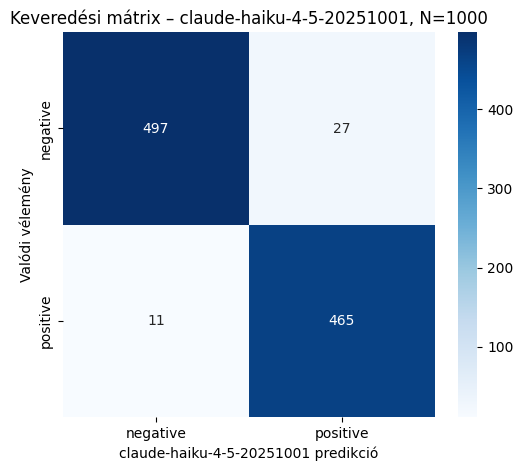

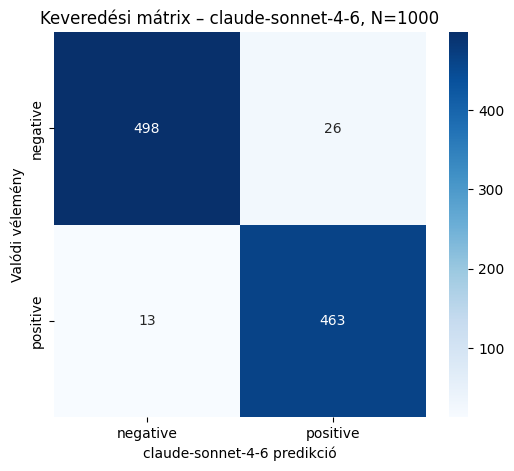

In [ ]:
# ============================================================
# 14. Keveredési mátrix ábrázolása
# ============================================================

for model_name in MODEL_NAMES:
    pred_col = f"claude_prediction_{model_name.replace('.', '_').replace('-', '_')}"
    eval_df = sample_df.dropna(subset=[pred_col]).copy()

    y_true = eval_df["sentiment"]
    y_pred = eval_df[pred_col]

    cm = confusion_matrix(y_true, y_pred, labels=["negative", "positive"])

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["negative", "positive"],
        yticklabels=["negative", "positive"]
    )
    plt.title(f"Keveredési mátrix – {model_name}, N={len(eval_df)}")
    plt.xlabel(f"{model_name} predikció")
    plt.ylabel("Valódi vélemény")
    plt.show()


## 15. Hibás besorolások listázása

Ez a cella segít a kvalitatív hibaanalízisben.
Megnézheted, mely review-kat sorolta tévesen pozitívnak vagy negatívnak a Claude.

A kétmodell-es változatban külön megjelenítjük a **Claude Haiku 4.5** és a
**Claude Sonnet 4.6** hibás besorolásait, hogy kvalitatív szinten is
összehasonlítható legyen a működésük.


In [ ]:
# ============================================================
# 15. Hibás besorolások listázása
# ============================================================

for model_name in MODEL_NAMES:
    pred_col = f"claude_prediction_{model_name.replace('.', '_').replace('-', '_')}"
    eval_df = sample_df.dropna(subset=[pred_col]).copy()
    errors_df = eval_df[eval_df["sentiment"] != eval_df[pred_col]].copy()

    print("=" * 80)
    print(f"Hibás besorolások – {model_name}")
    print("Hibás besorolások száma:", len(errors_df))

    display(errors_df[["review", "sentiment", pred_col]].head(10))


Hibás besorolások – claude-haiku-4-5-20251001
Hibás besorolások száma: 38


,review,sentiment,claude_prediction_claude_haiku_4_5_20251001
20,"The production quality, cast, premise, authent...",positive,negative
37,This was a popular movie probably because of t...,negative,positive
62,Hammerhead is a combination between the mad sc...,negative,positive
69,"OK, imagine that every state in the US, nay, e...",negative,positive
148,It's telling that as of the entry of this comm...,negative,positive
159,... so I thought I'd throw in a few words abou...,negative,positive
164,"Creepshow 2 had a lot of potential, they just ...",negative,positive
244,There is a DVD published in the UK in 2002 Cod...,negative,positive
266,"No this is not an Ed Wood movie. ""Angora Love""...",positive,negative
277,The thing I remember most about this film is t...,positive,negative


Hibás besorolások – claude-sonnet-4-6
Hibás besorolások száma: 39


,review,sentiment,claude_prediction_claude_sonnet_4_6
2,The film quickly gets to a major chase scene w...,negative,positive
20,"The production quality, cast, premise, authent...",positive,negative
50,A ruthless assassin has been hired to eliminat...,negative,positive
62,Hammerhead is a combination between the mad sc...,negative,positive
69,"OK, imagine that every state in the US, nay, e...",negative,positive
140,This may sound crazy to even the people who re...,negative,positive
145,"I liked the quiet noir of the first part, the ...",positive,negative
148,It's telling that as of the entry of this comm...,negative,positive
159,... so I thought I'd throw in a few words abou...,negative,positive
244,There is a DVD published in the UK in 2002 Cod...,negative,positive


## 16. Rövid kutatásmódszertani értelmezés

Ez a notebook egy **LLM-alapú sentiment osztályozási pilot** megoldást valósít meg.
A mintaalapú megközelítés előnye, hogy:

- gyorsan kipróbálható ugyanaz az elemzési pipeline több modellen,
- ellenőrizhető, hogy a különböző Claude-modellek mennyire stabilan reprodukálják az IMDb-címkéket,
- a kvantitatív mutatók mellett kvalitatív hibaanalízis is végezhető,
- ugyanazon mintán közvetlenül összehasonlítható a **Claude Haiku 4.5** és a **Claude Sonnet 4.6** teljesítménye.

Ez a megoldás különösen hasznos előkészítő, pilot vagy benchmark-jellegű kutatásokban,
ahol a cél nemcsak az osztályozás, hanem a modellek viselkedésének összevetése is.


In [ ]:
# ============================================================
# 16/A. Megjegyzés a további bővítéshez
# ============================================================

print("A Claude Haiku 4.5 vs Sonnet 4.6 összehasonlító notebook előkészítése elkészült.")


A Claude Haiku 4.5 vs Sonnet 4.6 összehasonlító notebook előkészítése elkészült.
